# SPY Options Expiry Day Pattern Analysis — v2.0 (Restructured)

**Capstone main notebook**, DAMO-699-3 MDA, University of Niagara Falls Canada.

This notebook implements the full capstone backtest end-to-end:

1. Configuration (§1) — IS / OOS windows. Strategy parameters come from
   `modules.config.capstone_v4_params` (single source of truth).
2. Setup and Imports (§2)
3. Data Layer (§3) — cache loading, expiry-date calendar.
4. Feature Engineering (§4) — `TechnicalIndicators` pipeline.
5. Portfolio Simulation — RSI Reversal v4.1 (§5) — IS + OOS via
   `run_simulation()`; produces `trades_df` and `trades_df_oos`.
6. Robustness Validation (§6) — Monte Carlo return-order permutation
   diagnostic (H₁ sub-criterion), walk-forward analysis (8 windows), and H₂
   two-proportion z-test.
7. Core Visualisations (§7) — the six charts cited in the final report.
8. Appendix A — Forward-looking watchlist for the next expiry (optional).

Numerical results from this notebook are reported in
`doc/capstone/final_report.md` §5 and §6.

---

## 1. Configuration

Strategy parameters (RSI threshold, consecutive count, hold days, commission,
IS/OOS window boundaries) are imported from `modules.config.capstone_v4_params`
rather than redefined here. Only the cache path and OOS end date are notebook-
level configuration; the OOS end date is auto-detected from the latest cached
trading day so the notebook stays reproducible as new data is added.

In [1]:
import os
import sys
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

from modules.config.capstone_v4_params import (
    RSI_THRESHOLD,
    MIN_CONSECUTIVE,
    HOLD_DAYS,
    COMMISSION,
    IS_START,
    IS_END,
    OOS_START,
)

CACHE_DIR = '../cache'
CONSTITUENT_DIR = '../cache/constituent_data'
SP500_LIST_FILE = '../cache/sp500_list.csv'

print('v4.1 parameters (frozen pre-OOS):')
print(f'  RSI_THRESHOLD    = {RSI_THRESHOLD}')
print(f'  MIN_CONSECUTIVE  = {MIN_CONSECUTIVE}')
print(f'  HOLD_DAYS        = {HOLD_DAYS}')
print(f'  COMMISSION       = {COMMISSION}')
print(f'  IS window        : {IS_START} -> {IS_END}')
print(f'  OOS start        : {OOS_START}')

v4.1 parameters (frozen pre-OOS):
  RSI_THRESHOLD    = 22
  MIN_CONSECUTIVE  = 3
  HOLD_DAYS        = 6
  COMMISSION       = 0.002
  IS window        : 2015-01-01 -> 2025-06-30
  OOS start        : 2025-07-01


## 2. Setup and Imports

All third-party libraries and project modules used downstream are imported here.
Only modules required by the linear flow (data → features → simulation →
robustness → visualisations → watchlist) are imported; legacy intraday/pattern
modules (`PerformanceCalculator`, `PatternAnalyzer`, `PredictivePatterns`,
`calculate_correlation_matrix`, `statistical_significance_test`) are deliberately
excluded from this notebook because their outputs are not cited in the final report.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Project modules — data layer
from modules.data import CacheManager, DataLoader, ExpiryCalculator

# Project modules — feature engineering
from modules.features import TechnicalIndicators, FeaturePipeline

# Project modules — portfolio simulation + metrics
from modules.evaluation.portfolio_simulator import run_simulation
from modules.evaluation.metrics import (
    calculate_composite_score,
    calculate_sharpe_ratio,
)

# Project modules — robustness validation
from modules.evaluation.robust_validation import MonteCarlo, WalkForward

# Project modules — forward-looking watchlist (appendix only)
from modules.evaluation import ExpiryScanner

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_palette('husl')

print('Imports OK')

Imports OK


## 3. Data Layer

`CacheManager` is used to confirm the cache is populated; `DataLoader` is the
downstream reader. `ExpiryCalculator` produces the monthly third-Friday calendar.

The latest cached trading day is detected by scanning a sample of the constituent
CSVs; this value is used as the OOS-end date so the notebook adapts when new
data is fetched by `CacheManager.update_cache()`.

In [3]:
cache_mgr = CacheManager(cache_dir=CONSTITUENT_DIR)
cache_mgr.sp500_list_file = SP500_LIST_FILE
loader = DataLoader(cache_dir=CONSTITUENT_DIR)

status = cache_mgr.get_cache_status()
print('Cache status:')
print(f"  latest date : {status['latest_date']}")
print(f"  num tickers : {status['num_tickers']}")

# Detect OOS end date dynamically from cached files
_sample = [f for f in os.listdir(CONSTITUENT_DIR) if f.endswith('.csv')][:50]
_latest = []
for _f in _sample:
    try:
        _df = pd.read_csv(os.path.join(CONSTITUENT_DIR, _f), usecols=['Date'])
        _latest.append(pd.to_datetime(_df['Date']).max())
    except Exception:
        pass
OOS_END = max(_latest).strftime('%Y-%m-%d') if _latest else '2026-04-01'
print(f'OOS end (auto-detected): {OOS_END}')

# Monthly expiry calendar over the full study window
expiry_dates = ExpiryCalculator.generate_expiry_dates(IS_START, OOS_END)
print(f'\nGenerated {len(expiry_dates)} monthly expiry dates')
print(f'  first : {expiry_dates[0].date()}')
print(f'  last  : {expiry_dates[-1].date()}')

Cache status:
  latest date : 2026-05-22
  num tickers : 512


OOS end (auto-detected): 2026-05-22

Generated 137 monthly expiry dates
  first : 2015-01-16
  last  : 2026-05-15


## 4. Feature Engineering

The simulation reads features from inside `run_simulation()`, so this section's
purpose is documentation and sanity-checking: it builds the same
`TechnicalIndicators` pipeline used internally and runs it against one ticker so
any pipeline regression surfaces here, before the multi-minute backtest below.

In [4]:
pipeline = FeaturePipeline([
    TechnicalIndicators(config={
        'rsi_period': 14,
        'ma_periods': [9, 20, 50],
        'macd_fast': 12,
        'macd_slow': 26,
        'macd_signal': 9,
        'bb_period': 20,
        'volume_ma_period': 20,
        'consecutive_lookback': 5,
    }),
])

print('Feature columns produced by pipeline:')
print('  ', pipeline.get_all_feature_names())

# Sanity-check on SPY (or fall back to the first ticker in the cache)
_check_ticker = 'SPY' if os.path.exists(os.path.join(CONSTITUENT_DIR, 'SPY.csv')) \
    else loader.get_sp500_tickers()[0]
_check_df = loader.load_ticker(_check_ticker, start_date=IS_START, end_date=OOS_END)
_check_df = pipeline.transform(_check_df)
print(f'\nSanity-check on {_check_ticker}: {len(_check_df)} rows, columns:')
print('  ', list(_check_df.columns))

Feature columns produced by pipeline:
   ['RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Position', 'Volume_SMA', 'Volume_Ratio', 'Consecutive_Count', 'Consecutive_Direction', 'SMA_9', 'MA_Distance_9', 'SMA_20', 'MA_Distance_20', 'SMA_50', 'MA_Distance_50']

Sanity-check on SPY: 2055 rows, columns:
   ['Symbol', 'Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'SMA_9', 'MA_Distance_9', 'SMA_20', 'MA_Distance_20', 'SMA_50', 'MA_Distance_50', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Position', 'Volume_SMA', 'Volume_Ratio', 'Consecutive_Count', 'Consecutive_Direction']


## 5. Portfolio Simulation — RSI Reversal Strategy v4.1

Backtest specification (frozen in `capstone_v4_params.py`):

- Signal date: trading day before each monthly expiry (third Friday)
- Entry: open price on the expiry date itself (T+1 after signal)
- Selection: top 3 tickers per expiry, ranked by ascending RSI
- Exit: close price `HOLD_DAYS` trading days after entry
- Commission: 0.2% round-trip per trade
- Max concurrent positions: 15

**IS window:** `IS_START` → `IS_END`. **OOS window:** `OOS_START` → `OOS_END`.
Expect a 3–8 minute runtime per window.

In [5]:
print('=' * 64)
print(f'IS  simulation : {IS_START} -> {IS_END}')
print('=' * 64)

trades_df = run_simulation(
    rsi_threshold=RSI_THRESHOLD,
    min_consecutive=MIN_CONSECUTIVE,
    hold_days=HOLD_DAYS,
    start_date=IS_START,
    end_date=IS_END,
    cache_dir=CACHE_DIR,
    verbose=True,
)
print(f'\nIS trades: {len(trades_df)}')
if not trades_df.empty:
    display(trades_df.head(10))

IS  simulation : 2015-01-01 -> 2025-06-30
⚠ Data validation failed for AAPL:
  - Close has 1460 outliers (13.9%)
⚠ Data validation failed for ADBE:
  - Close has 1124 outliers (11.2%)


⚠ Data validation failed for ADSK:
  - Close has 1065 outliers (10.3%)


⚠ Data validation failed for AMAT:
  - Close has 1271 outliers (12.1%)
⚠ Data validation failed for AMD:
  - Close has 1451 outliers (13.3%)


⚠ Data validation failed for ARE:
  - OHLC logic data quality issues detected (3 rows affected, 0.1%)
⚠ Data validation failed for AVB:
  - OHLC logic data quality issues detected (3 rows affected, 0.1%)
⚠ Data validation failed for AVGO:
  - Close has 333 outliers (7.9%)
⚠ Data validation failed for AVY:
  - Close has 584 outliers (5.6%)
⚠ Data validation failed for AXON:
  - Close has 376 outliers (7.0%)
⚠ Data validation failed for AZO:
  - Close has 536 outliers (6.1%)


⚠ Data validation failed for BEN:
  - OHLC logic data quality issues detected (5 rows affected, 0.0%)


...

2022-04-15 — 2 signals, 111 total trades so far.
2022-05-20 — 3 signals, 114 total trades so far.
2022-06-17 — 3 signals, 117 total trades so far.
2022-09-16 — 3 signals, 120 total trades so far.
2022-11-18 — 1 signals, 121 total trades so far.
2022-12-16 — 3 signals, 124 total trades so far.
2023-01-20 — 3 signals, 127 total trades so far.
2023-02-17 — 1 signals, 128 total trades so far.


2023-03-17 — 1 signals, 129 total trades so far.
2023-04-21 — 1 signals, 130 total trades so far.
2023-05-19 — 3 signals, 133 total trades so far.
2023-08-18 — 3 signals, 136 total trades so far.
2023-09-15 — 1 signals, 137 total trades so far.
2023-10-20 — 3 signals, 140 total trades so far.
2023-12-15 — 1 signals, 141 total trades so far.
2024-01-19 — 3 signals, 144 total trades so far.


2024-02-16 — 1 signals, 145 total trades so far.
2024-03-15 — 3 signals, 148 total trades so far.
2024-04-19 — 3 signals, 151 total trades so far.
2024-05-17 — 2 signals, 153 total trades so far.
2024-06-21 — 3 signals, 156 total trades so far.
2024-07-19 — 2 signals, 158 total trades so far.
2024-10-18 — 3 signals, 161 total trades so far.
2024-11-15 — 3 signals, 164 total trades so far.
2024-12-20 — 3 signals, 167 total trades so far.


2025-01-17 — 1 signals, 168 total trades so far.
2025-02-21 — 3 signals, 171 total trades so far.
2025-03-21 — 1 signals, 172 total trades so far.
2025-04-17 — 1 signals, 173 total trades so far.
2025-05-16 — 1 signals, 174 total trades so far.
2025-06-20 — 3 signals, 177 total trades so far.

IS trades: 177


,ticker,signal_date,entry_date,exit_date,entry_price,exit_price,gross_return,net_return,rsi_at_signal,consecutive_at_signal,vix_regime_at_signal
0,AIG,2015-01-15,2015-01-16,2015-01-27,41.2470,41.4337,0.004526,0.002526,8.473118,5,Medium
1,CFG,2015-01-15,2015-01-16,2015-01-27,17.8109,18.8406,0.057813,0.055813,10.312899,5,Medium
2,GE,2015-01-15,2015-01-16,2015-01-27,129.6450,134.4360,0.036955,0.034955,10.491782,5,Medium
3,MO,2015-03-19,2015-03-20,2015-03-30,33.0965,32.5602,-0.016204,-0.018204,15.975561,3,Low
4,TPR,2015-05-14,2015-05-15,2015-05-26,29.8932,28.8586,-0.034610,-0.036610,12.263727,4,Low
5,EMR,2015-07-16,2015-07-17,2015-07-27,42.7637,40.4601,-0.053868,-0.055868,18.689571,3,Low
6,NEM,2015-07-16,2015-07-17,2015-07-27,18.0960,14.7266,-0.186196,-0.188196,20.798762,5,Low
7,STLD,2015-07-16,2015-07-17,2015-07-27,16.5033,16.0131,-0.029703,-0.031703,21.845512,3,Low
8,JBHT,2015-08-20,2015-08-21,2015-08-31,72.0902,68.0633,-0.055859,-0.057859,11.065399,4,Medium
9,KKR,2015-08-20,2015-08-21,2015-08-31,16.5816,15.8750,-0.042613,-0.044613,12.061856,4,Medium


In [6]:
print('=' * 64)
print(f'OOS simulation : {OOS_START} -> {OOS_END}')
print('=' * 64)

trades_df_oos = run_simulation(
    rsi_threshold=RSI_THRESHOLD,
    min_consecutive=MIN_CONSECUTIVE,
    hold_days=HOLD_DAYS,
    start_date=OOS_START,
    end_date=OOS_END,
    cache_dir=CACHE_DIR,
    verbose=True,
)
print(f'\nOOS trades: {len(trades_df_oos)}')

OOS simulation : 2025-07-01 -> 2026-05-22
⚠ Data validation failed for AAPL:
  - Close has 1460 outliers (13.9%)
⚠ Data validation failed for ADBE:
  - Close has 1124 outliers (11.2%)
⚠ Data validation failed for ADSK:
  - Close has 1065 outliers (10.3%)


⚠ Data validation failed for AMAT:
  - Close has 1271 outliers (12.1%)
⚠ Data validation failed for AMD:
  - Close has 1451 outliers (13.3%)


⚠ Data validation failed for ARE:
  - OHLC logic data quality issues detected (3 rows affected, 0.1%)
⚠ Data validation failed for AVB:
  - OHLC logic data quality issues detected (3 rows affected, 0.1%)
⚠ Data validation failed for AVGO:
  - Close has 333 outliers (7.9%)
⚠ Data validation failed for AVY:
  - Close has 584 outliers (5.6%)
⚠ Data validation failed for AXON:
  - Close has 376 outliers (7.0%)
⚠ Data validation failed for AZO:
  - Close has 536 outliers (6.1%)


⚠ Data validation failed for BEN:
  - OHLC logic data quality issues detected (5 rows affected, 0.0%)


⚠ Data validation failed for C:
  - Close has 2253 outliers (15.8%)
⚠ Data validation failed for CAT:
  - Close has 748 outliers (5.3%)
⚠ Data validation failed for CCL:
  - Volume has 1152 outliers (12.2%)


...

⚠ Data validation failed for PCG:
  - Volume has 1112 outliers (9.5%)
  - OHLC logic data quality issues detected (6 rows affected, 0.1%)
⚠ Data validation failed for PGR:
  - Close has 1102 outliers (11.0%)
⚠ Data validation failed for PH:
  - Close has 693 outliers (6.7%)
⚠ Data validation failed for PHM:
  - Close has 614 outliers (6.0%)
⚠ Data validation failed for PWR:
  - Close has 561 outliers (10.5%)
⚠ Data validation failed for PYPL:
  - Close has 174 outliers (6.4%)
⚠ Data validation failed for Q:
  - Volume has 18 outliers (12.9%)


⚠ Data validation failed for SATS:
  - Close has 186 outliers (12.7%)
⚠ Data validation failed for SNPS:
  - Close has 1239 outliers (14.4%)
⚠ Data validation failed for SPGI:
  - Close has 1038 outliers (10.1%)


⚠ Data validation failed for TER:
  - Close has 652 outliers (6.6%)
⚠ Data validation failed for TKO:
  - Volume has 461 outliers (7.2%)
⚠ Data validation failed for TMO:
  - Close has 742 outliers (7.6%)
⚠ Data validation failed for TT:
  - Close has 1099 outliers (10.7%)
⚠ Data validation failed for TXN:
  - Close has 707 outliers (6.3%)
⚠ Data validation failed for USB:
  - OHLC logic data quality issues detected (6 rows affected, 0.1%)


⚠ Data validation failed for VST:
  - Close has 366 outliers (16.1%)
⚠ Data validation failed for WEC:
  - Volume has 579 outliers (5.5%)
⚠ Data validation failed for WMT:
  - Large date gaps detected (>10 trading days)
⚠ Data validation failed for XYZ:
  - Close has 295 outliers (11.2%)
⚠ Data validation failed for ZBRA:
  - Large date gaps detected (>10 trading days)
Loaded 435 tickers.


2025-07-18 — 1 signals, 1 total trades so far.
2025-08-15 — 2 signals, 3 total trades so far.
2025-09-19 — 3 signals, 6 total trades so far.
2025-10-17 — 3 signals, 9 total trades so far.
2025-11-21 — 3 signals, 12 total trades so far.
2025-12-19 — 3 signals, 15 total trades so far.
2026-01-16 — 3 signals, 18 total trades so far.
2026-03-20 — 3 signals, 21 total trades so far.
2026-05-15 — 3 signals, 24 total trades so far.

OOS trades: 24


In [7]:
def _portfolio_summary(df, label):
    """Print and return composite-score metrics for a trades_df window."""
    if df is None or df.empty:
        print(f'{label}: no trades')
        return None
    rets = df['net_return'].values
    n = len(rets)
    win_rate = (rets > 0).mean()
    gross_profit = rets[rets > 0].sum() if (rets > 0).any() else 0.0
    gross_loss = abs(rets[rets < 0].sum()) if (rets < 0).any() else 0.0
    pf = gross_profit / gross_loss if gross_loss > 0 else (float('inf') if gross_profit > 0 else 0.0)
    sharpe = float(calculate_sharpe_ratio(rets * 100))
    cum = (1 + rets).cumprod()
    run_max = np.maximum.accumulate(cum)
    mdd = float(abs(((cum - run_max) / run_max).min())) if n > 0 else 0.0
    composite = calculate_composite_score(pf, sharpe, win_rate, mdd)
    print(f'\n{label}:')
    print(f'  Trades        : {n}')
    print(f'  Win rate      : {win_rate:.1%}')
    print(f'  Profit factor : {pf:.2f}')
    print(f'  Sharpe        : {sharpe:.2f}')
    print(f'  Max drawdown  : {mdd:.1%}')
    print(f'  Composite     : {composite:.4f}')
    return {'pf': pf, 'sharpe': sharpe, 'win_rate': win_rate, 'mdd': mdd, 'composite': composite}


is_metrics  = _portfolio_summary(trades_df,     f'IS  ({IS_START} -> {IS_END})')
oos_metrics = _portfolio_summary(trades_df_oos, f'OOS ({OOS_START} -> {OOS_END})')

if is_metrics and oos_metrics:
    gap = abs(is_metrics['composite'] - oos_metrics['composite'])
    status = 'PASS' if gap < 0.05 else 'REVIEW (gap > 0.05 threshold)'
    print('\n' + '=' * 64)
    print(f'IS  composite : {is_metrics["composite"]:.4f}')
    print(f'OOS composite : {oos_metrics["composite"]:.4f}')
    print(f'Gap           : {gap:.4f}  [{status}]')
    print('=' * 64)


IS  (2015-01-01 -> 2025-06-30):
  Trades        : 177
  Win rate      : 53.1%
  Profit factor : 1.35
  Sharpe        : 1.43
  Max drawdown  : 54.1%
  Composite     : 0.5567

OOS (2025-07-01 -> 2026-05-22):
  Trades        : 24
  Win rate      : 58.3%
  Profit factor : 2.84
  Sharpe        : 5.46
  Max drawdown  : 21.4%
  Composite     : 0.8096

IS  composite : 0.5567
OOS composite : 0.8096
Gap           : 0.2530  [REVIEW (gap > 0.05 threshold)]


## 6. Robustness Validation

Three pre-registered tests (see proposal §5.6 / §7.6):

1. **Monte Carlo return-order permutation** — H₁ sub-criterion: shuffles
   `net_return` 500 times (seed = 42) and compares the observed composite to
   the permutation distribution. This is a path-ordering diagnostic, not a
   random-entry/ticker-selection test; see the caveat below and report §7.5.
2. **Walk-forward** — temporal stability across 8 non-overlapping windows
   (3-year IS / 1-year OOS, OOS years 2018–2025).
3. **H₂ z-test** — two-proportion z-test on win rate, High-VIX vs Low-VIX
   sub-samples of the IS trades.

In [8]:
print('Monte Carlo permutation test (500 shuffles, seed=42)')
print('-' * 64)

mc = MonteCarlo(trades_df)
mc_p_value, mc_null_dist = mc.run()

observed_composite = is_metrics['composite'] if is_metrics else 0.0
print(f'Observed composite     : {observed_composite:.4f}')
print(f'Null distribution mean : {mc_null_dist.mean():.4f}')
print(f'Null 95th percentile   : {np.percentile(mc_null_dist, 95):.4f}')
print(f'p-value                : {mc_p_value:.4f}')
print(f'  ({int(mc_p_value * 500)} of 500 permutations scored >= observed)')
if mc_p_value < 0.05:
    print('=> H1 supported (p < 0.05)')
else:
    print('=> H1 not supported at 0.05 level')

Monte Carlo permutation test (500 shuffles, seed=42)
----------------------------------------------------------------
Observed composite     : 0.5567
Null distribution mean : 0.5569
Null 95th percentile   : 0.5567
p-value                : 1.0000
  (500 of 500 permutations scored >= observed)
=> H1 not supported at 0.05 level


> **Interpretation caveat (report §7.5).** The p = 1.000 above is a **degenerate** result, not a
> clean randomness verdict. Shuffling `net_return` leaves Profit Factor, Sharpe, and Win Rate
> unchanged (they are order-invariant); only Max Drawdown varies. The observed drawdown (54.1%)
> already saturates the composite's 30% drawdown cap to its floor (0), so every permutation
> necessarily scores ≥ the observed composite — forcing p = 1.000 by construction. This test
> probes only the return *ordering* (path/drawdown); it does **not** test random ticker/entry
> selection. The report's H₁ no-edge conclusion therefore rests on H₂ (large-sample, §5.2), H₃
> (ML, §5.3), and the beta-vs-alpha analysis (§5.5), not on this p-value.

### 6.3 Beyond the degenerate shuffle — valid market-beta benchmarks

The return-shuffle Monte Carlo above is **degenerate** (report §7.5): it leaves Profit Factor, Sharpe and Win Rate unchanged and saturates the drawdown sub-score, forcing `p = 1.000`. The three benchmarks below are the **load-bearing** tests of H₁ — they let Profit Factor, Sharpe, Win Rate *and* Max Drawdown all vary, and they pit the rule against the two free explanations it must beat: **random stock-picking** and **simply holding SPY**.

All three reproduce the canonical numbers in `final_report.md` (§3.7, §5.1, §5.5, §8.2) and the standalone audit script `outputs/compute_benchmarks.py`. They share one preload of all-ticker OHLC + features (next cell); expect ~2–3 min, and they do **not** need the walk-forward cell to have run.

In [ ]:
# Preload OHLC + features for every ticker (shared by the random-entry MC and the expiry-premium scan).
# Mirrors outputs/compute_benchmarks.py so the printed numbers match the report and poster.
_loader = DataLoader(cache_dir=CONSTITUENT_DIR)
_pipe = FeaturePipeline([TechnicalIndicators(config={
    'rsi_period': 14, 'ma_periods': [9, 20, 50], 'macd_fast': 12, 'macd_slow': 26,
    'macd_signal': 9, 'bb_period': 20, 'volume_ma_period': 20, 'consecutive_lookback': 5})])
_OOS_END = '2026-05-22'

ALL_DATA = {}
for _tk in _loader.get_sp500_tickers():
    try:
        _d = _loader.load_ticker(_tk, start_date='2014-06-01', end_date=_OOS_END)
        if _d is None or len(_d) < 60:
            continue
        _d = _pipe.transform(_d)
        if 'Date' not in _d.columns:
            _d = _d.reset_index()
        _d['Date'] = pd.to_datetime(_d['Date'])
        ALL_DATA[_tk] = _d.reset_index(drop=True)
    except Exception:
        continue
print(f'Preloaded {len(ALL_DATA)} tickers with technical features.')

#### Portfolio-level random-entry Monte Carlo — the valid H₁ test

1,000 random portfolios drawn on the rule's **own entry dates and per-date trade counts**, each random pick held the same 6 days net of the same 0.2% cost. Unlike the return shuffle, this varies Profit Factor, Sharpe, Win Rate and Max Drawdown together, so it can actually discriminate selection skill. Expected: rule near the **62nd percentile, p ≈ 0.378** — indistinguishable from random picking (report §5.1 / §7.5).

In [ ]:
def _composite(rets):
    rets = np.asarray(rets, float)
    wr = (rets > 0).mean()
    gp = rets[rets > 0].sum(); gl = abs(rets[rets < 0].sum())
    pf = gp / gl if gl > 0 else (float('inf') if gp > 0 else 0.0)
    sharpe = float(calculate_sharpe_ratio(rets * 100))
    cum = (1 + rets).cumprod()
    mdd = float(abs(((cum - np.maximum.accumulate(cum)) / np.maximum.accumulate(cum)).min()))
    return float(calculate_composite_score(pf, sharpe, wr, mdd))

_pos = {tk: {d.astype('datetime64[D]'): i for i, d in enumerate(df['Date'].values)}
        for tk, df in ALL_DATA.items()}
_tickers = list(ALL_DATA.keys())

def _trade_ret(tk, entry_date):
    df = ALL_DATA[tk]
    p = _pos[tk].get(np.datetime64(pd.Timestamp(entry_date), 'D'))
    if p is None or p + HOLD_DAYS >= len(df):
        return None
    o = df['Open'].iloc[p]; c = df['Close'].iloc[p + HOLD_DAYS]
    return (c / o - 1 - COMMISSION) if o > 0 else None

_rng = np.random.default_rng(42)
_counts = trades_df.sort_values('entry_date').groupby('entry_date').size()
_obs = _composite(trades_df['net_return'].values)
_null = []
for _ in range(1000):
    _r = []
    for _ed, _k in _counts.items():
        for _tk in _rng.choice(_tickers, size=int(_k), replace=False):
            _v = _trade_ret(_tk, _ed)
            if _v is not None:
                _r.append(_v)
    if len(_r) >= 10:
        _null.append(_composite(_r))
_null = np.array(_null)
_pct = float((_null < _obs).mean() * 100)
_p_re = float((_null >= _obs).mean())
print(f'Rule composite : {_obs:.4f}')
print(f'Null median    : {np.median(_null):.4f}')
print(f'Percentile     : {_pct:.1f}th')
print(f'p-value        : {_p_re:.3f}  ->  not significant; indistinguishable from random stock-picking')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(_null, bins=34, color='#9AA6B5', alpha=0.7, edgecolor='white')
ax.axvline(_obs, color='#A41E22', linewidth=3,
           label=f'rule {_obs:.3f}  ({_pct:.0f}th pct, p={_p_re:.2f})')
ax.set_title('Portfolio-level random-entry Monte Carlo (1,000 random portfolios)')
ax.set_xlabel('Composite score'); ax.set_ylabel('Random portfolios'); ax.legend()
plt.tight_layout(); plt.show()

#### SPY matched-window benchmark — beta vs alpha

Match every trade to SPY's return over its **identical** entry→exit window. The per-trade excess is the selection alpha (expected non-significant, p ≈ 0.627); compounded over the same windows, the rule's picks (≈ +101%) **trail** simply buying SPY on those dates (≈ +166%). SPY data in the cache starts 2018, so calendar buy-and-hold spans 2018–2026 (report §3.7 / §5.5).

In [ ]:
_spy = (pd.read_csv(os.path.join(CONSTITUENT_DIR, 'SPY.csv'), parse_dates=['Date'])
          .set_index('Date').sort_index())
_si = _spy.index
_t = trades_df.sort_values('entry_date')
_stock_g, _spy_g, _net = [], [], []
for _, _r in _t.iterrows():
    _ei = _si.searchsorted(_r['entry_date']); _xi = _si.searchsorted(_r['exit_date'])
    if _ei >= len(_si) or _xi >= len(_si):
        continue
    _spy_g.append(_spy.iloc[_xi]['Close'] / _spy.iloc[_ei]['Open'] - 1)
    _stock_g.append(_r['gross_return']); _net.append(_r['net_return'])
_stock_g = np.array(_stock_g); _spy_g = np.array(_spy_g); _net = np.array(_net)

_tt = stats.ttest_rel(_stock_g, _spy_g)
print('Per-trade matched to SPY (same windows):')
print(f'  stock gross  : {_stock_g.mean()*100:+.2f}%   SPY same-window: {_spy_g.mean()*100:+.2f}%')
print(f'  alpha        : {(_stock_g-_spy_g).mean()*100:+.2f}%  (paired t={_tt.statistic:.2f}, p={_tt.pvalue:.3f}) -> not significant')

_rule_eq = (1 + _net).cumprod(); _spy_eq = (1 + _spy_g).cumprod()
print(f'\nMatched cumulative over {len(_net)} windows:')
print(f'  rule picks   : {(_rule_eq[-1]-1)*100:+.0f}%   buy SPY same dates: {(_spy_eq[-1]-1)*100:+.0f}%')
print(f'  rule beats SPY in {(_net > _spy_g).mean()*100:.0f}% of windows')

_full = _spy['Close']; _fc = (1 + _full.pct_change().fillna(0)).cumprod()
_fmdd = abs(((_fc - _fc.cummax()) / _fc.cummax()).min())
_fyrs = (_full.index[-1] - _full.index[0]).days / 365.25
print(f'\nSPY buy-and-hold {_full.index[0].date()} -> {_full.index[-1].date()}:')
print(f'  +{(_fc.iloc[-1]-1)*100:.0f}% cumulative, CAGR {((_fc.iloc[-1])**(1/_fyrs)-1)*100:.1f}%, '
      f'max drawdown {_fmdd*100:.1f}%   (rule IS max drawdown 54.1%)')

fig, ax = plt.subplots(figsize=(11, 4.6))
_d = _t['entry_date'].values[:len(_net)]
ax.plot(_d, (_spy_eq - 1) * 100, color='#B45309', linewidth=2.6, label='Buy SPY on the same dates')
ax.plot(_d, (_rule_eq - 1) * 100, color='#0B2545', linewidth=2.6, label="The rule's stock picks")
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_title("Same money, same days: the rule's picks trail just buying SPY")
ax.set_xlabel('Trade entry date'); ax.set_ylabel('Cumulative return (%)'); ax.legend()
plt.tight_layout(); plt.show()

#### Expiry vs non-expiry premium — a real footprint, not a tradeable edge

Split the forward 6-day net return of **every** RSI < 22 & ≥3-red signal by whether the signal day immediately precedes a monthly expiry. Pre-expiry signals return materially more — the mechanism leaves a footprint — but the pre-expiry signals cluster within only ~84 independent expiry days, so treating each expiry day as one observation the gap is **not significant (p ≈ 0.10)**, and it does not survive top-3 selection + costs (report §8.2).

In [ ]:
_exp = pd.to_datetime(ExpiryCalculator.generate_expiry_dates(IS_START, IS_END))
_eset = set(np.datetime64(d, 'D') for d in _exp.values)
_pre, _other, _pre_by_day = [], [], {}
for _tk, _df in ALL_DATA.items():
    _d = _df[(_df['Date'] >= IS_START) & (_df['Date'] <= IS_END)].reset_index(drop=True)
    if 'RSI' not in _d or 'Consecutive_Count' not in _d:
        continue
    for _i in range(len(_d) - HOLD_DAYS - 1):
        if _d['RSI'].iloc[_i] < RSI_THRESHOLD and _d['Consecutive_Count'].iloc[_i] >= MIN_CONSECUTIVE:
            _o = _d['Open'].iloc[_i + 1]; _c = _d['Close'].iloc[_i + 1 + HOLD_DAYS]
            if _o <= 0:
                continue
            _ret = _c / _o - 1 - COMMISSION
            _nxt = np.datetime64(pd.Timestamp(_d['Date'].iloc[_i + 1]), 'D')
            if _nxt in _eset:
                _pre.append(_ret); _pre_by_day.setdefault(_nxt, []).append(_ret)
            else:
                _other.append(_ret)
_pre = np.array(_pre); _other = np.array(_other)
_dm = np.array([np.mean(v) for v in _pre_by_day.values()])

print(f'Day before expiry : {_pre.mean()*100:+.2f}%  (n={len(_pre)}, win {(_pre>0).mean()*100:.1f}%)')
print(f'All other days    : {_other.mean()*100:+.2f}%  (n={len(_other)}, win {(_other>0).mean()*100:.1f}%)')
print(f'Gap               : {(_pre.mean()-_other.mean())*100:+.2f}%')
print(f'Naive Welch t-test           : p = {stats.ttest_ind(_pre, _other, equal_var=False).pvalue:.2e}  (treats all signals as independent)')
_ct = stats.ttest_1samp(_dm, _other.mean())
print(f'Clustered by {len(_dm)} expiry days  : t = {_ct.statistic:.2f}, p = {_ct.pvalue:.2f}  -> footprint, not a robust/tradeable edge')

In [9]:
print('Walk-forward analysis (8 windows, 3-yr IS / 1-yr OOS)')
print('Expected runtime: 20-60 minutes (8 x run_simulation)')
print('-' * 64)

wf = WalkForward(cache_dir=CACHE_DIR)
wf_results = wf.run(verbose=True)

display(wf_results[['window', 'oos_start', 'oos_end',
                     'pf', 'sharpe', 'win_rate', 'max_drawdown', 'composite']]
        .round(4))

_non_null = wf_results['composite'].dropna()
print(f'\nOOS composite stats : mean={_non_null.mean():.4f}, '
      f'min={_non_null.min():.4f}, max={_non_null.max():.4f}')
print(f'Windows with composite > 0   : {(_non_null > 0).sum()} / {len(_non_null)}')
print(f'Windows with composite > 0.5: {(_non_null > 0.5).sum()} / {len(_non_null)}')

Walk-forward analysis (8 windows, 3-yr IS / 1-yr OOS)
Expected runtime: 20-60 minutes (8 x run_simulation)
----------------------------------------------------------------
Window OOS 2018: IS 2015-01-01–2017-12-31, OOS 2018-01-01–2018-12-31
⚠ Data validation failed for AAPL:
  - Close has 1460 outliers (13.9%)
⚠ Data validation failed for ADBE:
  - Close has 1124 outliers (11.2%)
⚠ Data validation failed for ADSK:
  - Close has 1065 outliers (10.3%)


⚠ Data validation failed for AMAT:


  - Close has 1271 outliers (12.1%)
⚠ Data validation failed for AMD:
  - Close has 1451 outliers (13.3%)
⚠ Data validation failed for ARE:
  - OHLC logic data quality issues detected (3 rows affected, 0.1%)
⚠ Data validation failed for AVB:
  - OHLC logic data quality issues detected (3 rows affected, 0.1%)
⚠ Data validation failed for AVGO:
  - Close has 333 outliers (7.9%)
⚠ Data validation failed for AVY:
  - Close has 584 outliers (5.6%)
⚠ Data validation failed for AXON:
  - Close has 376 outliers (7.0%)
⚠ Data validation failed for AZO:
  - Close has 536 outliers (6.1%)


⚠ Data validation failed for BEN:
  - OHLC logic data quality issues detected (5 rows affected, 0.0%)
⚠ Data validation failed for C:
  - Close has 2253 outliers (15.8%)
⚠ Data validation failed for CAT:
  - Close has 748 outliers (5.3%)
⚠ Data validation failed for CCL:
  - Volume has 1152 outliers (12.2%)


⚠ Data validation failed for CIEN:
  - Close has 173 outliers (11.8%)
⚠ Data validation failed for COHR:
  - Close has 88 outliers (6.0%)
⚠ Data validation failed for COST:
  - Close has 901 outliers (9.0%)
⚠ Data validation failed for CRH:
  - Volume has 571 outliers (10.7%)
  - Close has 344 outliers (6.4%)
⚠ Data validation failed for CSX:
  - Close has 1155 outliers (10.1%)


...

⚠ Data validation failed for TER:
  - Close has 652 outliers (6.6%)
⚠ Data validation failed for TKO:
  - Volume has 461 outliers (7.2%)
⚠ Data validation failed for TMO:
  - Close has 742 outliers (7.6%)
⚠ Data validation failed for TT:
  - Close has 1099 outliers (10.7%)
⚠ Data validation failed for TXN:
  - Close has 707 outliers (6.3%)


⚠ Data validation failed for USB:
  - OHLC logic data quality issues detected (6 rows affected, 0.1%)
⚠ Data validation failed for VST:
  - Close has 366 outliers (16.1%)
⚠ Data validation failed for WEC:
  - Volume has 579 outliers (5.5%)
⚠ Data validation failed for WMT:
  - Large date gaps detected (>10 trading days)


⚠ Data validation failed for XYZ:
  - Close has 295 outliers (11.2%)
⚠ Data validation failed for ZBRA:
  - Large date gaps detected (>10 trading days)


,window,oos_start,oos_end,pf,sharpe,win_rate,max_drawdown,composite
0,2018,2018-01-01,2018-12-31,7.6039,10.1466,0.7500,0.0405,0.9297
1,2019,2019-01-01,2019-12-31,2.4654,6.3566,0.6154,0.0357,0.9052
2,2020,2020-01-01,2020-12-31,inf,16.0867,1.0000,0.0000,1.0000
3,2021,2021-01-01,2021-12-31,1.9535,4.2560,0.6000,0.0852,0.8693
4,2022,2022-01-01,2022-12-31,1.2297,1.3423,0.5238,0.2431,0.5498
5,2023,2023-01-01,2023-12-31,0.2179,-8.5306,0.1765,0.4136,0.0734
6,2024,2024-01-01,2024-12-31,1.5465,2.9010,0.5769,0.0596,0.8062
7,2025,2025-01-01,2025-12-31,1.8985,3.3432,0.5600,0.2263,0.7811



OOS composite stats : mean=0.7393, min=0.0734, max=1.0000
Windows with composite > 0   : 8 / 8
Windows with composite > 0.5: 7 / 8


In [10]:
print('H2 two-proportion z-test: High-VIX vs Low-VIX win rate')
print('-' * 64)

high_trades = trades_df[trades_df['vix_regime_at_signal'] == 'High']
low_trades  = trades_df[trades_df['vix_regime_at_signal'] == 'Low']
med_trades  = trades_df[trades_df['vix_regime_at_signal'] == 'Medium']

for label, sub in [('Low', low_trades), ('Medium', med_trades), ('High', high_trades)]:
    if len(sub) > 0:
        wr = (sub['net_return'] > 0).mean()
        print(f'  {label:<7s}: n={len(sub):>4d}  win rate = {wr:.1%}')

n_high = len(high_trades)
n_low  = len(low_trades)
if n_high >= 5 and n_low >= 5:
    wins_high = (high_trades['net_return'] > 0).sum()
    wins_low  = (low_trades['net_return']  > 0).sum()
    wr_high   = wins_high / n_high
    wr_low    = wins_low  / n_low

    p_pool = (wins_high + wins_low) / (n_high + n_low)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_high + 1 / n_low))
    z_stat = (wr_high - wr_low) / se if se > 0 else 0.0
    p_one_sided = 1 - stats.norm.cdf(z_stat)

    print(f'\n  High-VIX  n={n_high}, wins={wins_high}, win rate={wr_high:.1%}')
    print(f'  Low-VIX   n={n_low},  wins={wins_low},  win rate={wr_low:.1%}')
    print(f'  z-statistic       : {z_stat:.3f}')
    print(f'  p-value (one-sided): {p_one_sided:.4f}')
    if p_one_sided < 0.05:
        print('  => H2 supported (p < 0.05)')
    else:
        print('  => H2 not supported at 0.05 level')
else:
    print(f'\n  Insufficient samples (High: {n_high}, Low: {n_low})')

H2 two-proportion z-test: High-VIX vs Low-VIX win rate
----------------------------------------------------------------
  Low    : n=  63  win rate = 52.4%
  Medium : n=  92  win rate = 48.9%
  High   : n=  22  win rate = 72.7%

  High-VIX  n=22, wins=16, win rate=72.7%
  Low-VIX   n=63,  wins=33,  win rate=52.4%
  z-statistic       : 1.663
  p-value (one-sided): 0.0482
  => H2 supported (p < 0.05)


> **Superseded — see `ml_validation.ipynb` §3b and report §5.2.** The z-test above runs on the
> **177 top-3 portfolio trades**, which leaves only **n = 22** High-VIX trades; the resulting
> "H₂ supported (p = 0.048)" is a small-sample artifact. Re-tested on the **full triggered-signal
> universe** (n = 207 High-VIX vs 110 Low-VIX), the gap disappears: 67.6% vs 67.3%, z = 0.065,
> **p = 0.474 — H₂ NOT supported**. The report adopts the full-universe result; this cell is
> retained only to document the original (superseded) portfolio-subset computation.

## 7. Core Visualisations

Six charts cited in the final report:

1. Equity curve vs SPY buy-and-hold (IS window)
2. RSI distribution at signal dates
3. Consecutive red-candle count distribution
4. Walk-forward OOS heatmap (8 windows × 5 metrics)
5. Monte Carlo return-order permutation distribution with observed composite marked
6. Win rate by VIX regime

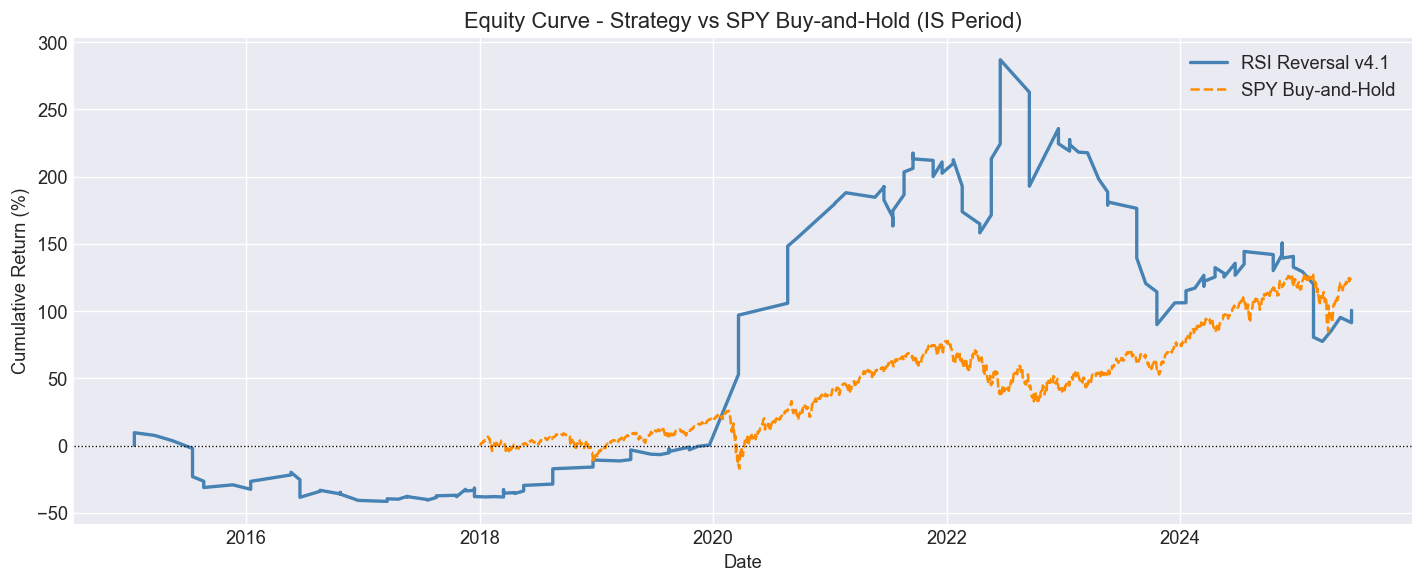

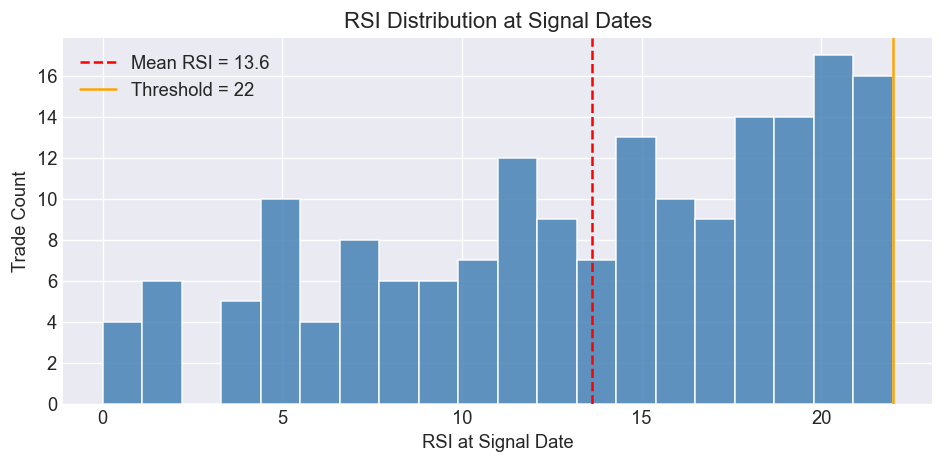

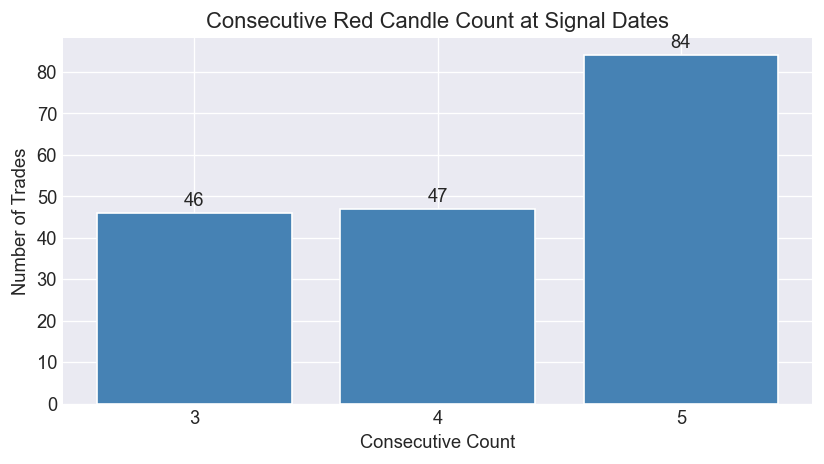

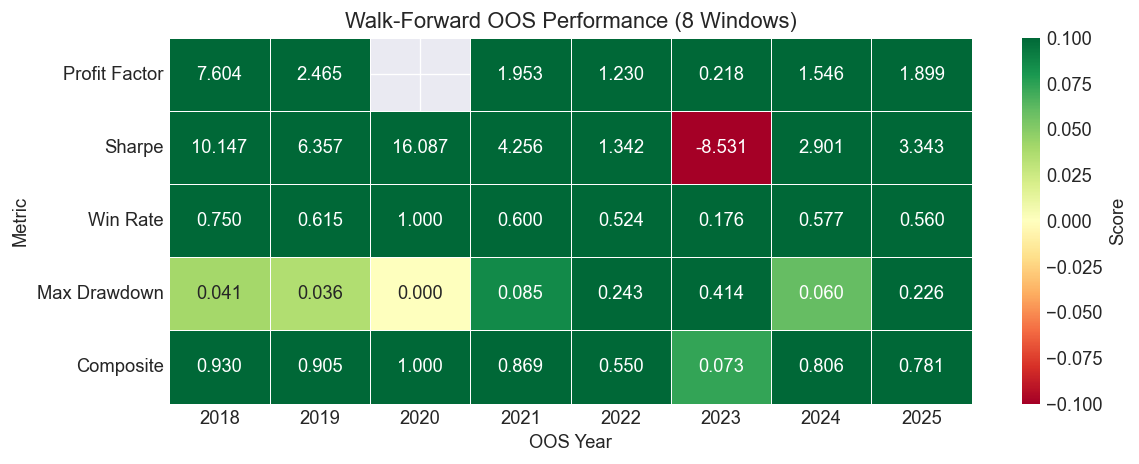

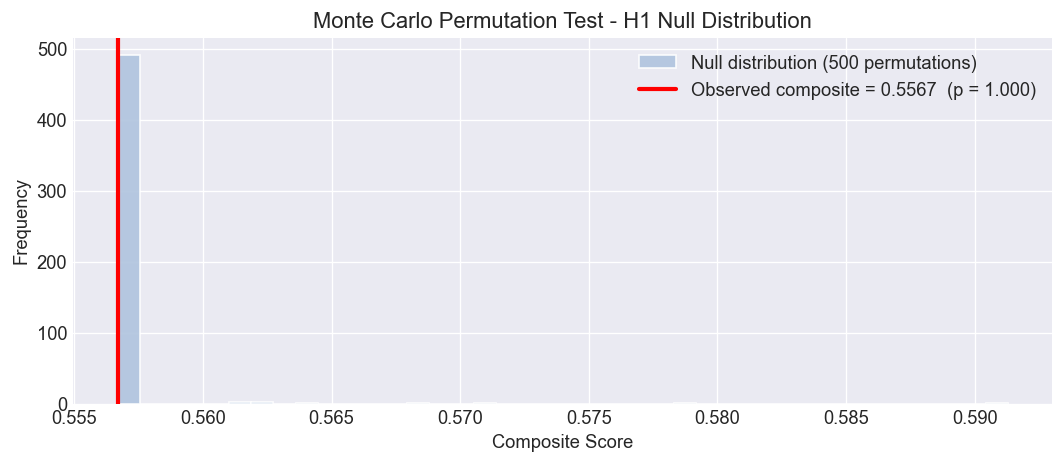

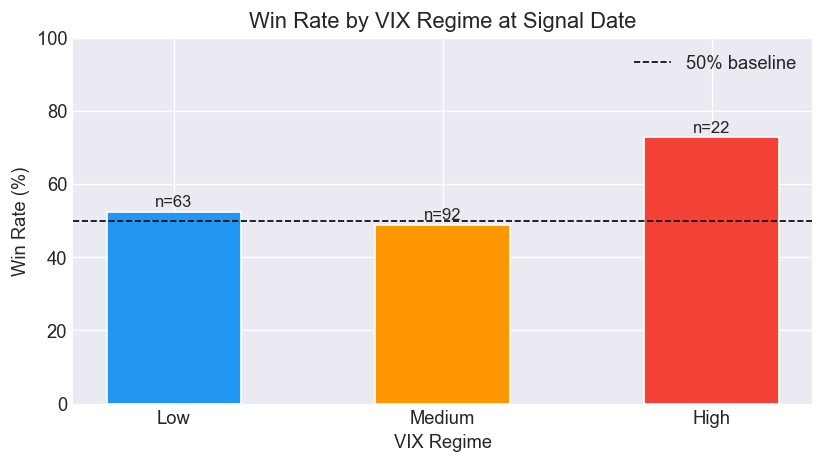


All 6 core visualisations rendered.


In [11]:
# Guard against running this cell before §5 / §6 have populated their outputs
_missing = [n for n in ['trades_df', 'wf_results', 'mc_null_dist',
                          'is_metrics', 'oos_metrics']
            if n not in dir() or eval(n) is None]
if _missing:
    raise RuntimeError('Run sections 5 and 6 first; missing: ' + ', '.join(_missing))

# --- Chart 1: Matched-window equity — rule's picks vs buying SPY on the same dates ---
# Capital-comparable: invest the same money on the same entry→exit windows (report §5.5).
fig1, ax1 = plt.subplots(figsize=(12, 5))
_o = trades_df.sort_values('entry_date')
_spy1 = (pd.read_csv(os.path.join(CONSTITUENT_DIR, 'SPY.csv'), parse_dates=['Date'])
           .set_index('Date').sort_index())
_idx1 = _spy1.index
_sg, _ng, _dt = [], [], []
for _, _rr in _o.iterrows():
    _e = _idx1.searchsorted(_rr['entry_date']); _x = _idx1.searchsorted(_rr['exit_date'])
    if _e >= len(_idx1) or _x >= len(_idx1):
        continue
    _sg.append(_spy1.iloc[_x]['Close'] / _spy1.iloc[_e]['Open'] - 1)
    _ng.append(_rr['net_return']); _dt.append(_rr['entry_date'])
_sg = np.array(_sg); _ng = np.array(_ng)
_rcum = (1 + _ng).cumprod(); _scum = (1 + _sg).cumprod()
ax1.plot(_dt, (_scum - 1) * 100, label='Buy SPY on the same dates', linewidth=2, color='darkorange')
ax1.plot(_dt, (_rcum - 1) * 100, label="RSI Reversal v4.1 (rule's picks)", linewidth=2, color='steelblue')
ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax1.set_title("Matched-window equity — rule's picks ({:+.0f}%) trail buying SPY ({:+.0f}%)".format(
    (_rcum[-1]-1)*100, (_scum[-1]-1)*100))
ax1.set_xlabel('Trade entry date'); ax1.set_ylabel('Cumulative Return (%)'); ax1.legend()
plt.tight_layout(); plt.show()

# --- Chart 2: RSI distribution at signal dates ---------------------------
fig2, ax2 = plt.subplots(figsize=(8, 4))
rsi_vals = trades_df['rsi_at_signal'].dropna()
ax2.hist(rsi_vals, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axvline(rsi_vals.mean(), color='red', linewidth=1.5, linestyle='--',
            label=f'Mean RSI = {rsi_vals.mean():.1f}')
ax2.axvline(RSI_THRESHOLD, color='orange', linewidth=1.5, linestyle='-',
            label=f'Threshold = {RSI_THRESHOLD}')
ax2.set_title('RSI Distribution at Signal Dates')
ax2.set_xlabel('RSI at Signal Date')
ax2.set_ylabel('Trade Count')
ax2.legend()
plt.tight_layout(); plt.show()

# --- Chart 3: Consecutive red candle count -------------------------------
fig3, ax3 = plt.subplots(figsize=(7, 4))
consec_vals = trades_df['consecutive_at_signal'].dropna().astype(int)
counts = consec_vals.value_counts().sort_index()
bars = ax3.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax3.bar_label(bars, padding=2)
ax3.set_title('Consecutive Red Candle Count at Signal Dates')
ax3.set_xlabel('Consecutive Count')
ax3.set_ylabel('Number of Trades')
ax3.set_xticks(counts.index)
plt.tight_layout(); plt.show()

# --- Chart 4: Walk-forward heatmap ---------------------------------------
wf_heat = wf_results[['window', 'pf', 'sharpe', 'win_rate',
                       'max_drawdown', 'composite']].copy()
wf_heat = wf_heat.set_index('window')
wf_heat.index = wf_heat.index.astype(str)
wf_heat.columns = ['Profit Factor', 'Sharpe', 'Win Rate',
                    'Max Drawdown', 'Composite']
fig4, ax4 = plt.subplots(figsize=(10, 4))
mask = wf_heat.isna()
sns.heatmap(wf_heat.T, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=ax4, mask=mask.T,
            cbar_kws={'label': 'Score'})
ax4.set_title('Walk-Forward OOS Performance (8 Windows)')
ax4.set_xlabel('OOS Year')
ax4.set_ylabel('Metric')
plt.tight_layout(); plt.show()

# --- Chart 5: Monte Carlo null distribution ------------------------------
fig5, ax5 = plt.subplots(figsize=(9, 4))
obs = is_metrics['composite']
ax5.hist(mc_null_dist, bins=40, color='lightsteelblue', edgecolor='white',
         alpha=0.9, label='Null distribution (500 permutations)')
ax5.axvline(obs, color='red', linewidth=2.5,
            label=f'Observed composite = {obs:.4f}  (p = {mc_p_value:.3f})')
ax5.set_title('Monte Carlo Permutation Test - H1 Null Distribution')
ax5.set_xlabel('Composite Score')
ax5.set_ylabel('Frequency')
ax5.legend()
plt.tight_layout(); plt.show()

# --- Chart 6: Win rate by VIX regime -------------------------------------
fig6, ax6 = plt.subplots(figsize=(7, 4))
regime_order = ['Low', 'Medium', 'High']
wr_by_regime = (
    trades_df.groupby('vix_regime_at_signal')['net_return']
             .apply(lambda x: (x > 0).mean())
             .reindex(regime_order)
)
n_by_regime = trades_df['vix_regime_at_signal'].value_counts().reindex(regime_order)
colors = ['#2196F3', '#FF9800', '#F44336']
bars6 = ax6.bar(regime_order, wr_by_regime.values * 100,
                color=colors, edgecolor='white', width=0.5)
for bar, n in zip(bars6, n_by_regime.values):
    ax6.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'n={n}', ha='center', va='bottom', fontsize=10)
ax6.axhline(50, color='black', linewidth=1, linestyle='--',
            label='50% baseline')
ax6.set_title('Win Rate by VIX Regime at Signal Date')
ax6.set_xlabel('VIX Regime')
ax6.set_ylabel('Win Rate (%)')
ax6.set_ylim(0, 100)
ax6.legend()
plt.tight_layout(); plt.show()

print('\nAll 6 core visualisations rendered.')

## Appendix A — Next Expiry Watchlist (Optional)

Forward-looking operational tool: scan the current S&P 500 universe for the
next monthly expiry and produce a watchlist matching the v4.1 signal rule.
Output is operational (used to size a real-world trade list), **not** a
capstone hypothesis test, and is not cited in the final report.

Skip this section if the goal is only to reproduce the report's IS/OOS results.

In [12]:
# Load the current universe across the full study window
tickers = loader.get_sp500_tickers()
stock_data = loader.load_sp500_batch(
    tickers,
    start_date=IS_START,
    end_date=OOS_END,
    validate=False,
)
print(f'Loaded {len(stock_data)} tickers for forward scan')

# Apply the same feature pipeline used by the simulation
for _t in stock_data:
    stock_data[_t] = pipeline.transform(stock_data[_t])

next_expiry = ExpiryCalculator.get_next_expiry()
print(f'Next expiry: {next_expiry.strftime("%Y-%m-%d (%A)")}')

scanner = ExpiryScanner()
watchlist = scanner.scan(stock_data, next_expiry)

if not watchlist.empty:
    print(f'\n{len(watchlist)} tickers match the v4.1 signal rule')
    display(watchlist[['Ticker', 'Pattern', 'Expected_Direction',
                        'Current_RSI', 'Consecutive_Candles',
                        'Candle_Direction', 'MA20_Dist', 'Volume_Ratio']])
else:
    print('\nNo tickers match the v4.1 signal rule for the next expiry.')

Loading 512 tickers...


✓ Loaded 512 tickers successfully
Loaded 512 tickers for forward scan


Next expiry: 2026-06-18 (Thursday)

143 tickers match the v4.1 signal rule


,Ticker,Pattern,Expected_Direction,Current_RSI,Consecutive_Candles,Candle_Direction,MA20_Dist,Volume_Ratio
0,AAPL,"Strong_Uptrend, Overbought_Momentum",Bullish,91.394505,4,green,6.751521,0.955998
1,AMD,"Strong_Uptrend, Overbought_Momentum",Bullish,75.167625,3,green,15.223417,0.964692
2,ARE,"Strong_Uptrend, Overbought_Momentum",Bullish,75.112652,3,green,7.646015,0.635429
3,BAX,"Strong_Uptrend, Overbought_Momentum",Bullish,72.630647,5,green,8.076127,0.882715
4,BF-B,"Oversold_Reversal, Deep_Pullback",Bullish,22.869148,3,red,-10.254428,0.000000
...,...,...,...,...,...,...,...,...
138,WMT,Deep_Pullback,Bullish,31.291759,3,red,-7.188529,1.600810
139,WSM,Strong_Uptrend,Bullish,65.250286,5,green,7.215344,0.740569
140,WST,Strong_Uptrend,Bullish,61.947555,5,green,2.943629,0.565557
141,XEL,Strong_Uptrend,Bullish,49.538934,5,green,1.115677,1.167761


---

*End of notebook. Numerical results are reported in*
`doc/capstone/final_report.md` §5 and §6.